#**LATIHAN**

1. Silahkan anda coba buat coding di atas di google colab anda
2. Simulasikan jenis file lain seperti kertas atau gunting, apakah citra inipun diklasifikasikan dengan benar
3. Silahkan anda coba2 beberapa nilai epoch, steps_per_epoch dan jenis optimizer, kira2 akan didapatkan nilai akurasi yang optimum kah?


# **1. Mengestrak file Zip**

Silahkan anda ekstrak file dan dan simpan di folder yang anda inginkan, namun sebelum itu silahkan anda ***mount*** dulu drive nya supaya dapat diakses oleh google colab.

In [ ]:
#mounting drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#ekstrak zip file dari origin folder ke target folder
import os
import zipfile

origin_fold ='/content/drive/MyDrive/PENGOLAHAN CITRA/Praktikum 11/gunting-batu-kertas.zip'
target_fold = '/content/drive/MyDrive/PENGOLAHAN CITRA/Praktikum 11/Dataset/'

extract_zip = zipfile.ZipFile(origin_fold, 'r')
extract_zip.extractall(target_fold)
extract_zip.close()

# **2. Mengakses file untuk data gambar gunting, batu, kertas**

Sebelum melakukan klasifikasi, file gambar gunting, batu dan kertas dicek dulu di masing-masing foldernya kemudian kita tampilkan jumlahnya serta sample gambarnya masing-masing.

In [ ]:
import os

#definisikan folder/direktori masing-masing gambar
dir_gunting = os.path.join('/content/drive/MyDrive/PENGOLAHAN CITRA/Praktikum 11/Dataset/scissors')
dir_batu= os.path.join('/content/drive/MyDrive/PENGOLAHAN CITRA/Praktikum 11/Dataset/rock')
dir_kertas = os.path.join('/content/drive/MyDrive/PENGOLAHAN CITRA/Praktikum 11/Dataset/paper')

#Menampilkan jumlah gambar di dalam masing-masing folder Gunting
print('Jumlah total gambar gunting:', len(os.listdir(dir_gunting)))
print('Jumlah total gambar batu:', len(os.listdir(dir_batu)))
print('Jumlah total gambar kertas:', len(os.listdir(dir_kertas)))

print("Menampilkan nama file gambar:")
file_gunting = os.listdir(dir_gunting)
print("Gunting:",file_gunting[:5])

file_batu = os.listdir(dir_batu)
print("Batu:",file_batu[:5])

file_kertas = os.listdir(dir_kertas)
print("Kertas:",file_kertas[:5])

Jumlah total gambar gunting: 750
Jumlah total gambar batu: 726
Jumlah total gambar kertas: 712
Menampilkan nama file gambar:
Gunting: ['0657zSfiTYzP2jrl.png', '0CSaM2vL2cWX6Cay.png', '0ePX1wuCc3et7leL.png', '0Flw60Z2MAWWKn6S.png', '0Ug54ifXRqqlZS2Z.png']
Batu: ['00nKV8oHuTGi20gq.png', '01dM3ewPIsnBICu1.png', '02vG75hQW9Vp4oTl.png', '0bioBZYFCXqJIulm.png', '0NDYNEoDui7o64gU.png']
Kertas: ['04l5I8TqdzF9WDMJ.png', '0a3UtNzl5Ll3sq8K.png', '0cb6cVL8pkfi4wF6.png', '0eqArS2GgsBeqgSn.png', '0Og76sl5CJhbxWWx.png']


# **3. Menampilkan gambar Gunting, Batu, Kertas dalam satu tampilan**

Untuk memgecek Citra yang ada dalam masing-masing folder, kita bisa menampilkan masing-masing citra menggunakan library matpolotlib. Karena jumlah citranya banyak, kita dapat menampilkan beberapa sample saja dari masing-masing kelas.

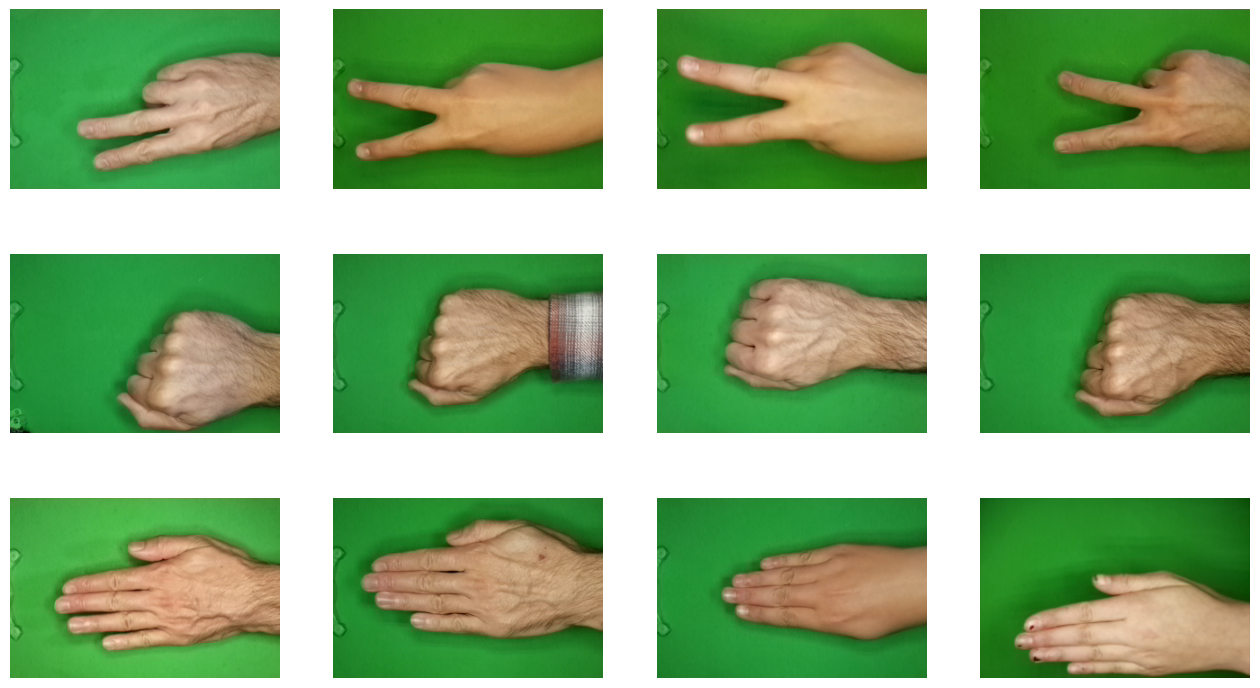

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

nrows = 3
ncols = 4

pic_index = 0

fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 3)

pic_index += 4
gbr_tampil_gunting  = [os.path.join(dir_gunting, fname)
                      for fname in file_gunting[pic_index-4:pic_index]]
gbr_tampil_batu     = [os.path.join(dir_batu, fname)
                      for fname in file_batu[pic_index-4:pic_index]]
gbr_tampil_kertas   = [os.path.join(dir_kertas, fname)
                      for fname in file_kertas[pic_index-4:pic_index]]

for i, img_path in enumerate(gbr_tampil_gunting+gbr_tampil_batu+gbr_tampil_kertas):
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off')

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()

#**4. Melakukan Augmentasi & Pemisahan Data menjadi Training dan Validation**

Augmentasi dilakukan untuk menambah variasi citra, untuk keperluan ini bisa digunakan library keras. Namun sebelumnya library ini dipanggil dulu dengan mengistallnya libray tersebut.

Selanjutnya dilakukan pemisahan data menjadi training dan validation menggunakan fungsi 'ImageDataGenerator'. Kali ini proporsi data trainig dan validation displit menjadi adalah 8:2 (80% training dan 20% validation).

Untuk keperluan itu, perlu diset folder untuk pemisahan data ini, dalam hal ini digunakan sbb : /content/drive/MyDrive/PENGOLAHAN CITRA/Praktikum 11/Dataset/. Silahkan anda sesuaikan dengan folder anda

In [ ]:
#installing keras
!pip install keras-preprocessing
import tensorflow as tf
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator

#spliting data menjadi training dan validation
BASIS_DIR = "/content/drive/MyDrive/PENGOLAHAN CITRA/Praktikum 11/Dataset/"
training_datagen = ImageDataGenerator(
      rescale = 1./255,

      #aumentasi data
	    rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest',

      #splitting 80% Data Training, 20% Data Validasi
      validation_split=0.2
      )

# **5. Labeling Data**

Pada tahap ini, citra akan diberi label 'training' dan 'validation', namun sebelumnya image size diubah menjadi 150 x 150 pixel untuk mempercepat proses training. Untuk kelas mode digunakan mode 'categorical'

In [ ]:
#generate data training
train_generator = training_datagen.flow_from_directory(
	BASIS_DIR,
	target_size=(150,150),
	class_mode='categorical',
  shuffle=True,
  subset='training'
  )

#generate data validation
validation_generator = training_datagen.flow_from_directory(
	BASIS_DIR,
	target_size=(150,150),
	class_mode='categorical',
 # shuffle=True,
  subset='validation'
  )

print(train_generator)

Found 1751 images belonging to 3 classes.
Found 437 images belonging to 3 classes.


#**6. Membangun Model Jaringan Saraf Tiruan**

Modei yang digunakan adalah model sequensial dengan 3 layer convolusi, 2 hidden layer (128 neuron dan 512 neuron) dan input image berdimensi 150x150 RGB

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(512, activation='relu'),

    tf.keras.layers.Dense(3, activation='softmax')
])

model.summary()
Model: "sequential_2"

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,183,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,265,795 (4.83 MB)

 Trainable params: 1,265,795 (4.83 MB)

 Non-trainable params: 0 (0.00 B)

#**7. Kompilasi dan Training Model**

Langkah selanjutnya adalah meng'compile' model CNN yang telah dibuat di atas dan dilanjutkan dengan melakukan training terhadap model CNN dengan menggunakan 20 kali iterasi dengan step per iterasi adalah 48 dan untuk validasi menggunakan 21 step, hal ini dipengaruhi oleh jumlah datasetnya, yaitu sebagai berikut:

Training: 1.750 samples / 32 batch_size = 55 steps

Validation: 438 samples / 32 batch_size = 14 steps

Saya juga menambahkan parameter learning rate = 0.0001 pad optimizer yang digunakan untuk hasil lebih maksimal.

In [ ]:
model.compile(loss = 'categorical_crossentropy',
              optimizer=tf.optimizers.Adam(learning_rate=0.0001),
              metrics=['accuracy'])


history=model.fit(
    train_generator,
    steps_per_epoch=55,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=14,
    verbose=2
    )

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
55/55 - 38s - 695ms/step - accuracy: 0.3598 - loss: 1.0934 - val_accuracy: 0.3432 - val_loss: 1.0957
Epoch 2/20
55/55 - 39s - 717ms/step - accuracy: 0.4575 - loss: 1.0520 - val_accuracy: 0.5103 - val_loss: 0.9993
Epoch 3/20
55/55 - 33s - 608ms/step - accuracy: 0.4957 - loss: 1.0064 - val_accuracy: 0.6041 - val_loss: 0.9472
Epoch 4/20
55/55 - 33s - 607ms/step - accuracy: 0.5260 - loss: 0.9649 - val_accuracy: 0.6133 - val_loss: 0.8939
Epoch 5/20
55/55 - 34s - 611ms/step - accuracy: 0.6117 - loss: 0.8963 - val_accuracy: 0.6568 - val_loss: 0.8258
Epoch 6/20
55/55 - 34s - 612ms/step - accuracy: 0.6756 - loss: 0.7956 - val_accuracy: 0.6957 - val_loss: 0.7276
Epoch 7/20
55/55 - 34s - 615ms/step - accuracy: 0.7362 - loss: 0.6874 - val_accuracy: 0.7780 - val_loss: 0.6187
Epoch 8/20
55/55 - 40s - 731ms/step - accuracy: 0.7841 - loss: 0.5841 - val_accuracy: 0.8009 - val_loss: 0.5629
Epoch 9/20
55/55 - 32s - 586ms/step - accuracy: 0.7824 - loss: 0.5722 - val_accuracy: 0.7872 - val_loss:

#**8. Melihat Akurasi Training dan Validasi dalam Grafik**

Untuk melihat berapa akurasi maksimum dari data training maupun validation yang didapatkan dari iterasi yang diberikan, kita bisa mem-plot akurasi model sbb :

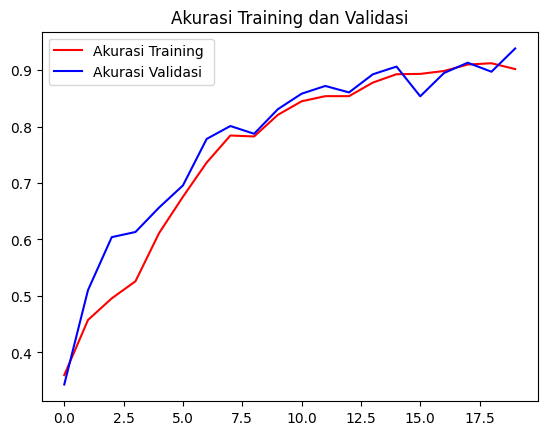

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Akurasi Training ')
plt.plot(epochs, val_acc, 'b', label='Akurasi Validasi')
plt.title('Akurasi Training dan Validasi')
plt.legend(loc=0)
plt.figure()
plt.show()

#**9. Simulasi Model untuk Klasifikasi Citra**

Untuk simulasi model, anda mencoba menguji file yang ada dalam dataset anda. Sebagai contoh di sini akan di uji 10 file pertama pada direktori 'batu', 'gunting' dan 'kertas',

=====BATU=====
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
00nKV8oHuTGi20gq.png
[[0. 1. 0.]]
Tangan Ini Menunjukkan bentuk BATU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
01dM3ewPIsnBICu1.png
[[0. 1. 0.]]
Tangan Ini Menunjukkan bentuk BATU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
02vG75hQW9Vp4oTl.png
[[0. 1. 0.]]
Tangan Ini Menunjukkan bentuk BATU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
0bioBZYFCXqJIulm.png
[[0. 1. 0.]]
Tangan Ini Menunjukkan bentuk BATU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
0NDYNEoDui7o64gU.png
[[0. 1. 0.]]
Tangan Ini Menunjukkan bentuk BATU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
0OEXfEooCXlljaEl.png
[[0. 1. 0.]]
Tangan Ini Menunjukkan bentuk BATU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
0P6uxM8Vr1DwySHe.png
[[0. 1. 0.]]
Tangan Ini Menunjukkan bentuk BATU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
19H63c0MWD56EWNq.png
[[0. 1. 0.]]
Tangan Ini Menunjukkan bentuk BATU
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1BqjHe5igJAgUjiN.png
[[0. 1. 0.]]
Tangan Ini Menunjukkan bentuk BATU
1/1 ━━━━━━━━━━━━━━━━━━

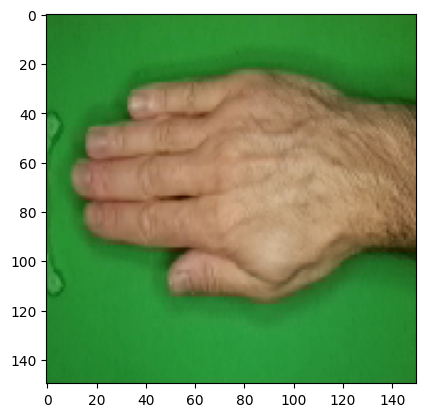

In [ ]:
import numpy as np
from google.colab import files
from keras.preprocessing import image
import os

print('=====BATU=====')
file_batu = os.listdir(dir_batu)
for filename in  file_batu[:10]:
    image_path = os.path.join(dir_batu, filename)
    img = image.load_img(image_path, target_size=(150, 150))
    imgplot = plt.imshow(img)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    images = np.vstack([x])
    classes = model.predict(images, batch_size=10)
    print(filename)
    print(classes)

    if classes[0][0]==1:
      print('Tangan Ini Menunjukkan bentuk KERTAS')
    elif classes[0][1]==1:
      print('Tangan Ini Menunjukkan bentuk BATU')
    elif classes[0][2]==1:
      print('Tangan Ini Menunjukkan bentuk GUNTING')
    else:
      print('Tidak Diketahui')
print('===============')
print()

print('=====GUNTING=====')
file_gunting = os.listdir(dir_gunting)
for filename in  file_gunting[:10]:
    image_path = os.path.join(dir_gunting, filename)
    img = image.load_img(image_path, target_size=(150, 150))
    imgplot = plt.imshow(img)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    images = np.vstack([x])
    classes = model.predict(images, batch_size=10)
    print(filename)
    print(classes)

    if classes[0][0]==1:
      print('Tangan Ini Menunjukkan bentuk KERTAS')
    elif classes[0][1]==1:
      print('Tangan Ini Menunjukkan bentuk BATU')
    elif classes[0][2]==1:
      print('Tangan Ini Menunjukkan bentuk GUNTING')
    else:
      print('Tidak Diketahui')
print('===============')
print()

print('=====KERTAS=====')
file_kertas = os.listdir(dir_kertas)
for filename in  file_kertas[:10]:
    image_path = os.path.join(dir_kertas, filename)
    img = image.load_img(image_path, target_size=(150, 150))
    imgplot = plt.imshow(img)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    images = np.vstack([x])
    classes = model.predict(images, batch_size=10)
    print(filename)
    print(classes)

    if classes[0][0]==1:
      print('Tangan Ini Menunjukkan bentuk KERTAS')
    elif classes[0][1]==1:
      print('Tangan Ini Menunjukkan bentuk BATU')
    elif classes[0][2]==1:
      print('Tangan Ini Menunjukkan bentuk GUNTING')
    else:
      print('Tidak Diketahui')
print('===============')
print()

#**10. Kesimpulan**

Berdasarkan parameter training yang sudah diubah-ubah didapatkan akurasi klasifikasi yang baik pada langkah 9. Training diubah parameternya berdasarkan pemisahan data yang dilakukan, yaitu 80% training dan 20% validation, karena pada contoh awal tidak dilakukan training pada seluruh dataset yang ada.

Silakan upload gambar tangan (Batu/Gunting/Kertas)


Saving 1oKnUgV2CdCaQUUX.png to 1oKnUgV2CdCaQUUX.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

=== DETAIL PREDIKSI ===
KERTAS: 99.73%
BATU: 0.19%
GUNTING: 0.08%


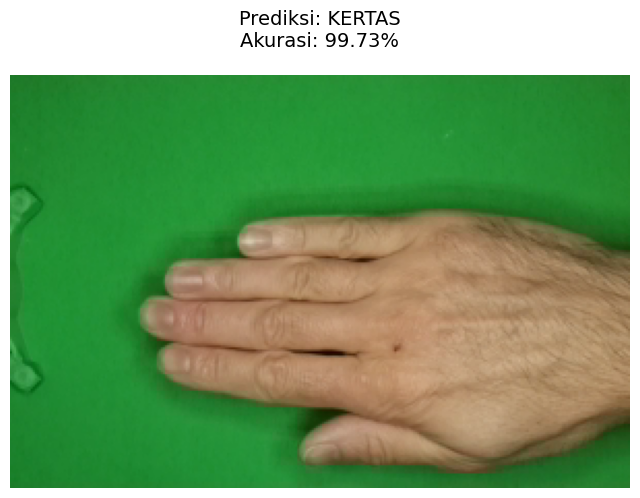

In [ ]:
import numpy as np
from keras.preprocessing import image
import matplotlib.pyplot as plt
from google.colab import files
import cv2
import os

# Fungsi untuk memprediksi gambar
def predict_uploaded_image(model):
    # Upload gambar via Colab
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Baca dan preprocess gambar
        img = image.load_img(filename, target_size=(150, 150))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0  # Normalisasi

        # Prediksi
        predictions = model.predict(img_array)
        class_names = ['KERTAS', 'BATU', 'GUNTING']
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100

        # Tampilkan gambar
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB))
        plt.axis('off')

        # Tampilkan hasil prediksi
        prediction_text = f"Prediksi: {class_names[predicted_class]}\nAkurasi: {confidence:.2f}%"
        plt.title(prediction_text, fontsize=14, pad=20)

        # Tampilkan probabilitas tiap kelas
        print("\n=== DETAIL PREDIKSI ===")
        for i, (class_name, prob) in enumerate(zip(class_names, predictions[0])):
            print(f"{class_name}: {prob*100:.2f}%")

        plt.show()


# Contoh penggunaan
print("Silakan upload gambar tangan (Batu/Gunting/Kertas)")
predict_uploaded_image(model)